In [9]:
import sympy as sp
import numpy as np 
import matplotlib.pyplot as plt

In [10]:
# Define symbols
θ1, θ2, θ3, l = sp.symbols('θ1 θ2 θ3 l', real=True)

# Jacobian matrix
J = sp.Matrix([
    [-sp.sin(θ1)*(l + l*sp.cos(θ2) + l*sp.cos(θ3 - θ2)), 
     sp.cos(θ1)*(-l*sp.sin(θ2) + l*sp.sin(θ3 - θ2)),
     sp.cos(θ1)*(-l*sp.sin(θ3 - θ2))],
    
    [0,
     l*sp.cos(θ2) + l*sp.sin(θ3 - θ2),
     -l*sp.sin(θ3 - θ2)],
    
    [sp.cos(θ1)*(l + l*sp.cos(θ2) + l*sp.cos(θ3 - θ2)),
     sp.sin(θ1)*(-l*sp.sin(θ2) + l*sp.sin(θ3 - θ2)),
     sp.sin(θ1)*(-l*sp.sin(θ3 - θ2))]
])

# Compute determinant
detJ = sp.simplify(J.det())
print("Determinant of J:")
sp.pprint(detJ)

Determinant of J:
     3                                 ⎛     π⎞             
-√2⋅l ⋅(cos(θ₂) + cos(θ₂ - θ₃) + 1)⋅sin⎜θ₂ + ─⎟⋅sin(θ₂ - θ₃)
                                       ⎝     4⎠             


In [21]:

def find_singularity(J, symbols, n=50, threshold=0.1):
    θ_syms = symbols[:3]
    l_syms = symbols[3:]
    l = 1
    
    det_expr = sp.simplify(J.det())
    det_func = sp.lambdify(θ_syms + l_syms, det_expr, 'numpy')
    
    θ1_grid = np.linspace(-np.pi, np.pi, n)
    θ2_grid = np.linspace(-np.pi, np.pi, n)
    θ3_grid = np.linspace(-np.pi, np.pi, n)
    
    surface_points = []
    
    for i in range(n):
        θ1 = θ1_grid[i]
        for j in range(n):
            θ2 = θ2_grid[j]
            det_vals = det_func(θ1, θ2, θ3_grid, l)
            
            zero_crossings = np.where(np.diff(np.sign(det_vals)))[0]
            
            for k in zero_crossings:
                surface_points.append([θ1, θ2, k])
    
    surface_points = np.array(surface_points)
    
    if len(surface_points) > 0:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(surface_points[:, 0], surface_points[:, 1], surface_points[:, 2],
                  c='red', s=2, alpha=0.6)
        ax.set_xlabel('θ1')
        ax.set_ylabel('θ2')
        ax.set_zlabel('θ3')
        ax.set_title('Singularity Surface (det=0)')
        plt.show()
    
    return surface_points

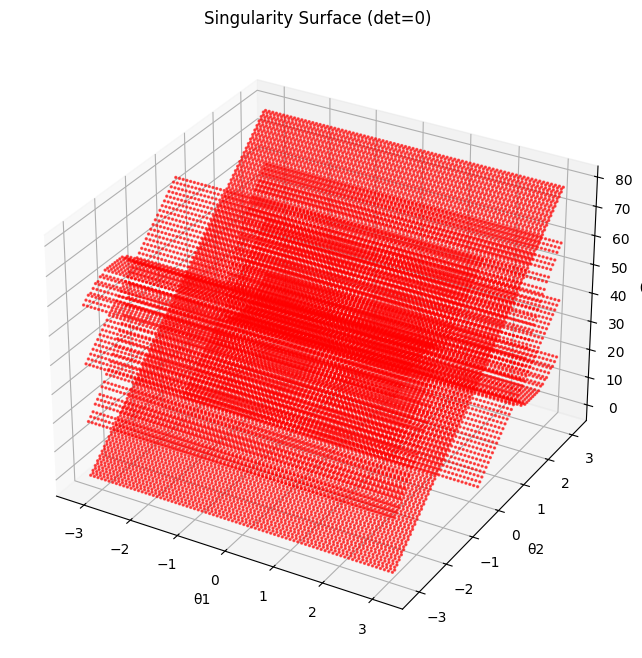

In [20]:
symbols = [θ1, θ2, θ3, l]
link_lengths = [1.0]
surface = find_singularity(J, symbols, n=80, threshold=0.1)